In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive')

Mounted at /content/drive


In [2]:
!pip install PyWavelets

In [3]:
import torch
import glob
import os
STAGE= 'GCRR'
STAGE_2= 'GRSB'
file_pattern_x = '/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_*.pt'
file_pattern_y = '/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_y_all_complete_*.pt'
file_pattern_target = f'/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/target_10/Target_{STAGE}_*.pt'
file_pattern_target_2 = f'/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/target_10/Target_{STAGE_2}_*.pt'


"""
上面路径当中存储的tensor都是用512窗口去滑动每一口井得到的，所以每口井的尾端难免会舍弃一些，从而与原数据形状不一致。
现在考虑：反总标准化+反组标准化这些tensor.
试验后得出结论：反标准化只用在画图当中，训练终点就是两次标准化的数据吧。
画图时，拿出一条残井tensor，做成standard.ipynb文件里数据的形状，再进行两次反标准化吧。
仔细一想似乎有别的办法
"""
# Get all files matching the pattern
x_files = glob.glob(file_pattern_x)
y_files = glob.glob(file_pattern_y)
target_files = glob.glob(file_pattern_target)
target_files_2 = glob.glob(file_pattern_target_2)

# Sort the files to ensure they are in the correct order
x_files.sort()
y_files.sort()
target_files.sort()
target_files_2.sort()

# List to store individual tensors
tensor_list_x = []
tensor_list_y = []
tensor_list_target = []
tensor_list_target_2 = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# file就是每口井
for file in x_files:
    # 查看tensor_list_x的测井顺序，用于提取井名
    print(f"Loading tensor from file: {file}")  # Print the file name
    tensor = torch.load(file,map_location=torch.device(device))
    well_len = tensor
    tensor_list_x.append(tensor)
print('\n')

for file in y_files:
    print(f"Loading tensor from file: {file}")  # Print the file name
    tensor = torch.load(file,map_location=torch.device(device))
    tensor_list_y.append(tensor)

print('\n')

for file in target_files:
    print(f"Loading tensor from file: {file}")  # Print the file name
    tensor = torch.load(file,map_location=torch.device(device))
    tensor_list_target.append(tensor)

print('\n')

for file in target_files_2:
    print(f"Loading tensor from file: {file}")  # Print the file name
    tensor = torch.load(file,map_location=torch.device(device))
    tensor_list_target_2.append(tensor)

# Concatenate all tensors along the first dimension
combined_tensor_x = torch.cat(tensor_list_x, dim=0)
combined_tensor_y = torch.cat(tensor_list_y, dim=0)
combined_tensor_target = torch.cat(tensor_list_target, dim=0)
combined_tensor_target_2 = torch.cat(tensor_list_target_2, dim=0)

print(f"Combined tensor shape: {combined_tensor_x.shape}")
print(f"Combined tensor shape: {combined_tensor_y.shape}")
print(f"Combined tensor shape: {combined_tensor_target.shape}")
print(f"Combined tensor shape: {combined_tensor_target_2.shape}")

Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_15.9-15.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_15.9-17.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.1-2.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.1-6 A.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.10-1.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.10-2.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.10-5.pt
Loading tenso

In [ ]:
## 数据增强
# 固定数据集的生成逻辑
import numpy as np
import math
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
# label making
# 长井
well_slice30 = []
well_slice30_2 = []
# 长井index
well_index_slice30 = []
# tensor_list_target_2&tensor_list_target index都一样
for _ in range(len(tensor_list_target_2)):
  if len(tensor_list_target_2[_]) > 30:
    well_slice30.append(tensor_list_target[_])
    well_slice30_2.append(tensor_list_target_2[_])
    well_index_slice30.append(_)
# 根据index来生成pt
combined_tensor_target = torch.cat(well_slice30, dim=0)#前两口井用作测试集
combined_tensor_target_2 = torch.cat(well_slice30_2, dim=0)#前两口井用作测试集
assert len(combined_tensor_target) == len(combined_tensor_target_2)

#print(tensor_list_target_2_pt.shape,tensor_list_target_2_pt.shape,well_index_slice30)

# 操作target张量，把GCRR和GRSB合并起来
combined_target = torch.cat((combined_tensor_target[:,1:,:],combined_tensor_target_2[:,1:3,:]),dim=1)

#tensor_list_target_2[well_index_slice30[0]]

# 把长井选取，做成pt
well_x = []
for _ in well_index_slice30:#前两口井用作测试集
  well_x.append(tensor_list_y[_])
well_x_pt = torch.cat(well_x, dim=0)



# 设置扰动的规模
perturbation_scale = 0.03
triangle_scale = 0.1
original_tensor = combined_target

# 确定 original_tensor 所在的设备
device = original_tensor.device

# 定义一个函数来生成周期性噪音
def periodic_noise(tensor, frequency=1.0):
    # 使用 tensor 的第一个维度（1024）来创建周期性变化
    indices = torch.arange(tensor.shape[0], device=device).unsqueeze(1).unsqueeze(2).float()
    periodic = torch.sin(2 * math.pi * frequency * indices / tensor.shape[0])
    return periodic.expand_as(tensor)

def periodic_noise_batch(tensor, min_freq=0.5, max_freq=5.0):
    device = tensor.device
    batch_size, channels, length = tensor.shape

    # 为每个样本生成随机 frequency
    frequencies = torch.rand(batch_size, 1, 1, device=device) * (max_freq - min_freq) + min_freq

    indices = torch.arange(length, device=device).view(1, 1, -1).float()

    periodic = torch.sin(2 * math.pi * frequencies * indices / length)

    # 确保 periodic 的形状与输入张量匹配
    periodic = periodic.expand(batch_size, channels, length)

    return periodic


# 创建 10 个扰动的副本
perturbed_labels = []
perturbed_inputs = []

for i in range(10):
    # 添加随机噪音和周期性噪音
    perturbed_label = (
        original_tensor
        + perturbation_scale * torch.randn_like(original_tensor)
        + triangle_scale * periodic_noise(original_tensor, frequency=0.5 + i * 0.1)#periodic_noise_batch(original_tensor)
    )
    perturbed_input = (
        well_x_pt
        + perturbation_scale * torch.randn_like(well_x_pt)
        + triangle_scale * periodic_noise(well_x_pt, frequency=0.5 + i * 0.1)#periodic_noise_batch(well_x_pt)
    )

    perturbed_labels.append(perturbed_label)
    perturbed_inputs.append(perturbed_input)

# 将所有扰动后的 tensors 组合在一起
combined_target = torch.cat(perturbed_labels, dim=0)
combined_tensor_y_ = torch.cat(perturbed_inputs, dim=0)

print(f"Shape of combined_target: {combined_target.shape}")
print(f"Shape of combined_tensor_y_: {combined_tensor_y_.shape}")

Shape of combined_target: torch.Size([10240, 5, 512])
Shape of combined_tensor_y_: torch.Size([10240, 4, 512])


In [ ]:
# 别糊涂
a = 0
for i in well_index_slice30:
 a+=len(tensor_list_y[i])
a

1024

In [ ]:
## 非数据增强
# 操作target张量，把GCRR和GRSB合并起来
combined_target = torch.cat((combined_tensor_target[:,1:,:],combined_tensor_target_2[:,1:3,:]),dim=1)
#combined_target = combined_tensor_target[:,1,:].unsqueeze(1)#CALI

combined_target.shape

torch.Size([1024, 5, 512])

In [ ]:
# 把预测张量的变量名统一，注意覆盖
combined_tensor_target = combined_target

In [ ]:
tensor_list_target[0].shape

torch.Size([34, 4, 512])

## 对于数据做处理。例如，反标准化，获取meta data来得到缺失索引用于成图。

In [ ]:
#拿个井做整井的预测成图
well_x_pt = tensor_list_x[1].clone()#tensor_list_x的有91个items，对应91口井
well_y_pt = tensor_list_y[1].clone()

# 取target和target_2的第一口井，cat一下，第一口井是15/9-15
#well_list_target_ = torch.cat((tensor_list_target[0][:,1:,:].clone(),tensor_list_target_2[0][:,1:3,:].clone()),dim=1)
#第二口井是15/9-17
well_list_target_ = torch.cat((tensor_list_target[1][:,1:,:].clone(),tensor_list_target_2[1][:,1:3,:].clone()),dim=1)
#well_list_target_ = tensor_list_target[0][:,1,:].clone().unsqueeze(1)
well_target_pt = well_list_target_.clone()


In [4]:
local_train_csv = '/content/drive/MyDrive/well log data mixing&incrementation/CSV_train.csv'
import pandas as pd
train_ori_set_2 = pd.read_csv(local_train_csv, engine = 'python',sep=';')
print('训练集读取完成！')

训练集读取完成！


In [ ]:
#15.9-15
well_name = '15/9-15'
single_well = train_ori_set_2[train_ori_set_2['WELL'] == f'{well_name}'].copy()
assert single_well.shape[0] != 0, "single_well is empty"
selected = single_well[['CALI', 'RSHA', 'RMED',  'RDEP', 'SP']].copy()
print(f'{well_name}元数据长度为',selected.shape)
selected = selected.reset_index(drop=True)#注意，滑动截取的井数据index都会reset，回想自己之前写的算法
"""
15/9-15井的元数据长度为17717，well_target_pt是512窗口滑动的该井数据，长度为17717-512+1=17,408 二者相差309
"""
selected


15/9-15元数据长度为 (17717, 5)


,CALI,RSHA,RMED,RDEP,SP
0,NaN,1.567587,1.567587,1.735962,45.884998
1,NaN,1.570050,1.570050,1.744778,46.435825
2,NaN,1.553659,1.553659,1.752990,46.375412
3,NaN,1.541216,1.541216,1.760675,46.352402
4,NaN,1.540456,1.540456,1.767360,46.329601
...,...,...,...,...,...
17712,7.776711,0.987094,0.987094,0.862399,130.657028
17713,7.779644,0.969350,0.969350,0.847839,130.781586
17714,7.792982,0.962780,0.962780,0.844712,130.755585
17715,NaN,0.973905,0.973905,0.839559,130.758560


In [ ]:
#这个cell应该用不到了
#用于结果展示,整个井的fea数量级回到原始数据的量级
def de_mean_var_norm(label, fea, target):
  """
  target = label in def mean_var_norm() parameters.
  standard_data用于de_mean_var_norm()函数的all_data_fea参数传入
  """
  df1_mean=target.mean()
  df1_std=target.std(ddof=0)  #避免std使用index=0的影响
  label_de = (label * df1_std) + df1_mean

  return label_de


# 载入元数据，用来反标准化真实标签和预测值,
standard_data = pd.read_csv('/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/standard_data.csv')
standard_data.head()

# 预测曲线
param['fea'] = ['CALI', 'RSHA', 'RMED',  'RDEP', 'SP']

# 经过组标准化的数据，还要经过总标准化，下面的反总标准化
all_data_fea = standard_data[param['fea']].copy() #只经过组标准化的
normd = train_stand[param['fea']].copy() #经过了总标准化的
all_data_fea_de = de_mean_var_norm(normd,param['fea'],all_data_fea) #反总标准化之后的

#这里照理来说要把stand_info,refer_well的计算过程加进来，但是我仔细思索，没有意义：预测值通过真实值来反标准化
#这样吧，根据真实值的反标准化与标准化之间的差值，加到预测值上，就得到预测值的反标准化值
destandard_data_fea = standard_by_group(standard_data_fea, stand_info, refer_well, param['fea'], True)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/standard_data.csv'

## 神经网络训练

In [ ]:
# Assuming your data is loaded into 'data' with shape (2035, 4, 512)
data = combined_tensor_y_ #combined_tensor_y 为避免链式
target = combined_tensor_target

# Split the data
train_size = len(combined_tensor_y_)
train_data = data[670:]#670是前两口井的切片数67*10=670
val_data = well_x_pt[67:]#避开测试集
test_data = data[:670]#测试集的两口长井

train_target = target[670:]
val_target = original_tensor[67:]
test_target = target[:670]



In [5]:
#from re import T
import numpy as np
import pandas as pd
import random



from matplotlib import pyplot as plt
import time

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm
from torch.optim import lr_scheduler
from math import exp
#import argparse
#from re import T

import os




In [6]:
#from pickle import TRUE

from typing import Union, Tuple, Optional
from torch.autograd import Variable


import math
from typing import Union, Tuple, Optional

from torch.utils.data import Dataset
from torch import Tensor
from torch.nn import Parameter

class Data:
    def __init__(self, input_sam, label):
        self.x = input_sam
        self.y = label
    def to(self, device):
        self.x = self.x.to(device)
        self.y = self.y.to(device)
        return self
class my_dataset(Dataset):
    def __init__(self, input, target):
        self.input = input  # (2035, 4, 512)
        self.target = target  # (2035, 1, 512)

    def __getitem__(self, idx):
        input_sam = self.input[idx]  # This will be of shape (4, 512)
        label = self.target[idx]  # This will be of shape (1, 512)

        # 如果input和target不是torch.Tensor，我们需要转换它们
        if not isinstance(input_sam, torch.Tensor):
            input_sam = torch.tensor(input_sam, dtype=torch.float32)
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(label, dtype=torch.float32)

        # 返回Data对象
        return Data(input_sam=input_sam, label=label)

    def __len__(self):
        return len(self.input)

def custom_collate(batch):
    input_sam = torch.stack([item.x for item in batch])
    label = torch.stack([item.y for item in batch])
    return Data(input_sam=input_sam, label=label)

In [7]:
from functools import reduce
import operator
def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul,
                    list(p.size()+(2,) if p.is_complex() else p.size()))
    return print(c)

In [8]:
#convolution in channel features
class conv_obj(nn.Module):
    def __init__(
        self,
        _in_channels: Union[int, Tuple[int, int]],
        _out_channels: int,
        cnn_in_channels: int,
        cnn_out_channels: int,
        batchsize: int = 3,
        down_up: bool = True, #default True == down
        poolstride: int = 2,
        onlypoolout:bool = True,
    ):
        super(conv_obj, self).__init__()
        self._in_channels = _in_channels
        self._out_channels = _out_channels
        self.cnn_in_channels = cnn_in_channels
        self.cnn_out_channels = cnn_out_channels
        self.batchsize = batchsize
        self.down_up = down_up
        self.poolstride = poolstride
        self.onlypoolout = onlypoolout


        if isinstance(_in_channels, int):
            _in_channels = (_in_channels, _in_channels)

        self.device = device
        print('device used in conv_obj：',self.device)


        if self.down_up == True:
            self.conv0 =  conv_down_conv_obj(cnn_in_channels,cnn_out_channels,onlypoolout,poolstride).to(self.device)
            self.conv1 =  conv_down_conv_obj(cnn_in_channels,cnn_out_channels,onlypoolout,poolstride).to(self.device)
            self.conv2 =  conv_down_conv_obj(cnn_in_channels,cnn_out_channels,onlypoolout,poolstride).to(self.device)
            self.conv3 =  conv_down_conv_obj(cnn_in_channels,cnn_out_channels,onlypoolout,poolstride).to(self.device)
        else:
            self.conv0 = conv_up_conv_obj(cnn_in_channels,cnn_out_channels,poolstride).to(self.device)
            self.conv1 = conv_up_conv_obj(cnn_in_channels,cnn_out_channels,poolstride).to(self.device)
            self.conv2 = conv_up_conv_obj(cnn_in_channels,cnn_out_channels,poolstride).to(self.device)
            self.conv3 = conv_up_conv_obj(cnn_in_channels,cnn_out_channels,poolstride).to(self.device)

    def forward(self, x):

        CIN,COUT,GIN,GOUT = self.cnn_in_channels,self.cnn_out_channels,self._in_channels,self._out_channels
        #print(x.shape)

        y = torch.zeros([self.batchsize,COUT,GOUT]).to(self.device)

        out_cat = torch.zeros([self.batchsize,COUT,GIN]).to(self.device)

        #print(x[0][0:self.batchsize * 4:4][:].shape)
        #print('y',y.shape)
        if self.onlypoolout == True:
            y[0 :self.batchsize * 4:4][:] = self.conv0(x[0:self.batchsize * 4:4][:])
            y[1 :self.batchsize * 4:4][:] = self.conv1(x[1:self.batchsize * 4:4][:])
            y[2 :self.batchsize * 4:4][:] = self.conv2(x[2:self.batchsize * 4:4][:])
            y[3 :self.batchsize * 4:4][:] = self.conv3(x[3:self.batchsize * 4:4][:])
        else:
            #temp = self.conv0(x[0][0:self.batchsize * 4:4][:])
            #print('temp length ',len(temp))
            #print('temp ',temp[0].shape)
            y[0 :self.batchsize * 4:4][:], out_cat[0 :self.batchsize * 4:4][:] = self.conv0(x[0:self.batchsize * 4:4][:])
            y[1 :self.batchsize * 4:4][:], out_cat[1 :self.batchsize * 4:4][:] = self.conv1(x[1:self.batchsize * 4:4][:])
            y[2 :self.batchsize * 4:4][:], out_cat[2 :self.batchsize * 4:4][:] = self.conv2(x[2:self.batchsize * 4:4][:])
            y[3 :self.batchsize * 4:4][:], out_cat[3 :self.batchsize * 4:4][:] = self.conv3(x[3:self.batchsize * 4:4][:])

        return y, out_cat

#用于conv_obj的下采样卷积模块
class conv_down_conv_obj(nn.Module):
    def __init__(self,in_ch,out_ch,onlypoolout,poolstride = 2):
        super(conv_down_conv_obj, self).__init__()
        self.onlypoolout = onlypoolout
        self.Conv = nn.Sequential(
            nn.Conv1d(in_channels=in_ch,out_channels=out_ch,kernel_size=7,stride=1,padding=3),
            nn.BatchNorm1d(out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ELU(),

            nn.Conv1d(in_channels=out_ch,out_channels=out_ch,kernel_size=7,stride=1,padding=3),
            nn.BatchNorm1d(out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ELU()
        )

        self.downsample= nn.Sequential(
            nn.MaxPool1d(5, stride=poolstride,padding = 2)
        )


    def forward(self,x):

        out_cat = self.Conv(x)
        out=self.downsample(out_cat)
        #print('out.size()',out.size(),'out.dtype',out.dtype,'out.type()',out.type())

        if self.onlypoolout==True:
            return out
        else:
            return out, out_cat

#用于conv_obj的上采样卷积模块
class conv_up_conv_obj(nn.Module):
    def __init__(self,in_ch,out_ch,poolstride = 2):
        super(conv_up_conv_obj, self).__init__()

        self.layers = nn.Sequential(
            nn.Conv1d(in_channels = in_ch, out_channels = 2*out_ch, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(2*out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ELU(),

            nn.Conv1d(in_channels = 2*out_ch, out_channels = 2*out_ch, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(2*out_ch),
            nn.LeakyReLU(negative_slope=0.2),

            nn.ConvTranspose1d(in_channels=2*out_ch,out_channels=out_ch,kernel_size=7,stride=poolstride,padding=3,output_padding=(poolstride-1)),
            nn.BatchNorm1d(out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ELU(),
        )

    def forward(self,x):
        out = self.layers(x)

        return out

#Unet结构上下采样部分的中间衔接（上采样）
class upsample(nn.Module):
    '''仅进行上采样（将上采样与和聚合模块分割开）'''
    def __init__(self,gnn_out_ch, cnn_in_ch, cnn_out_ch, bsize, poolstride=2):
        super(upsample,self).__init__()
        self.bsize = bsize
        self.cout = cnn_out_ch
        self.gout = gnn_out_ch

        self.conv1 = conv_up_conv_obj(cnn_in_ch,cnn_out_ch,poolstride)
        self.conv0 = conv_up_conv_obj(cnn_in_ch,cnn_out_ch,poolstride)
        self.conv2 = conv_up_conv_obj(cnn_in_ch,cnn_out_ch,poolstride)
        self.conv3 = conv_up_conv_obj(cnn_in_ch,cnn_out_ch,poolstride)

    def forward(self,x):
        y = torch.zeros([self.bsize, self.cout, self.gout]).to(device)

        y[0 :self.bsize * 4:4][:] = self.conv0(x[0:self.bsize * 4:4][:])
        y[1 :self.bsize * 4:4][:] = self.conv1(x[1:self.bsize * 4:4][:])
        y[2 :self.bsize * 4:4][:] = self.conv2(x[2:self.bsize * 4:4][:])
        y[3 :self.bsize * 4:4][:] = self.conv3(x[3:self.bsize * 4:4][:])

        return y

#Unet结构下采样部分中，补偿torch.cat导致的通道数翻倍
class cat_fuse(nn.Module):
    """
    卷积模块，减半通道数。
    """
    def __init__(self,cnn_in_ch,cnn_out_ch):
        super(cat_fuse,self).__init__()

        self.Conv = nn.Sequential(
            nn.Conv1d(in_channels=cnn_in_ch,out_channels=cnn_out_ch,kernel_size=7,stride=1,padding=3),
            nn.BatchNorm1d(cnn_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
        )
    def forward(self,x):
        y = self.Conv(x)

        return y

#mlp用于学习mean与std
class mean_std_head(torch.nn.Module):
    def __init__(self):
        super(mean_std_head, self).__init__()

        self.mlp1 = MLP(4*512, 4*128, 4*32)
        self.mlp2 = MLP(4*32, 4*8, 8)

        #self.dropout = nn.Dropout(p=0.5)


    def forward(self, x, batch):

        y = torch.stack(unbatch(x, batch))
        y = torch.flatten(y,1,-1)

        y = self.mlp1(y)
        #y = self.dropout(y)
        y = self.mlp2(y)
        #y = self.dropout(y)
        #print('全连接后y', y.size(), y)

        return y


class MLP(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super(MLP, self).__init__()

        self.mlp = nn.Sequential(
            nn.Linear(in_ch, hid_ch),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Linear(hid_ch, hid_ch),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Linear(hid_ch, out_ch),
        )

    def forward(self, x):
        x = self.mlp(x)

        return x

# Fourier Feature Extractor core
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        """
        3D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1


        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights4 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfftn(x, dim=[-1]).to(x.device)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1] = \
            self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1.to(x.device))
        out_ft[:, :, -self.modes1:] = \
            self.compl_mul1d(x_ft[:, :, -self.modes1:], self.weights2.to(x.device))
        out_ft[:, :, :self.modes1] = \
            self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights3.to(x.device))
        out_ft[:, :, -self.modes1:] = \
            self.compl_mul1d(x_ft[:, :, -self.modes1:], self.weights4.to(x.device))

        #Return to physical space
        x = torch.fft.irfftn(out_ft, s=(x.size(-1)))
        return x

class MLP_(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP_, self).__init__()
        self.mlp1 = nn.Conv1d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv1d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.gelu(x)
        x = self.mlp2(x)
        return x

class FourierFeatureExtractor(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, mid_channels=8, modes1=8):
        super(FourierFeatureExtractor,self).__init__()
        self.fconv1 = SpectralConv1d(in_channels, mid_channels, modes1)
        self.fconv2 = SpectralConv1d(mid_channels, mid_channels, modes1)
        self.fconv3 = SpectralConv1d(mid_channels, mid_channels, modes1)
        self.mlp1 = MLP_(mid_channels, mid_channels, mid_channels)
        self.mlp2 = MLP_(mid_channels, mid_channels, mid_channels)
        self.mlp3 = MLP_(mid_channels, mid_channels, mid_channels)
        self.w1 = nn.Conv1d(in_channels, mid_channels, 1)
        self.w2 = nn.Conv1d(mid_channels, mid_channels, 1)
        self.w3 = nn.Conv1d(mid_channels, mid_channels, 1)
        self.out_proj = MLP_(mid_channels, out_channels, mid_channels)


    def forward(self,x):
        # x (32,4,512)
        # f-1
        x_f = self.fconv1(x)
        x_f = self.mlp1(x_f)

        # c-1
        x_c =self.w1(x)

        x = x_f + x_c
        x = F.gelu(x)
        # f-2
        x_f = self.fconv2(x)
        x_f = self.mlp2(x_f)

        # c-2
        x_c =self.w2(x)
        x = x_f + x_c
        x = F.gelu(x)

        # f-3
        x_f = self.fconv3(x)
        x_f = self.mlp3(x_f)

        # c-3
        x_c =self.w3(x)
        x = x_f + x_c
        x = F.gelu(x)

        x = self.out_proj(x)
        return x


# U-Net
#meta model to be trained
class FNPG(torch.nn.Module):

    def __init__(self,gnn_ch,batchsize,fea_litho,head,drop):
        super(FNPG, self).__init__()
        """
        input:(batch_size,num_curves,channels,sam_len)
        output:(batch_size,num_curves,sam_len)
        """
        CNN_ch = [4,32,64,128,256,512] #gnn_ch = [512,256,128,64,32]

        result_ch=5

        self.bsize = batchsize
        self.fea_n = len(fea_litho)

        #self.head = mean_std_head()#到底还用不用神经网络去反标准化了？
        self.gd0 = conv_obj(gnn_ch[0],gnn_ch[1],CNN_ch[0],CNN_ch[1],batchsize = batchsize,onlypoolout=False,down_up = True)
        self.gd1 = conv_obj(gnn_ch[1],gnn_ch[2],CNN_ch[1],CNN_ch[2],batchsize = batchsize,onlypoolout=False,down_up = True)
        self.gd2 = conv_obj(gnn_ch[2],gnn_ch[3],CNN_ch[2],CNN_ch[3],batchsize = batchsize,onlypoolout=False,down_up = True)

        self.FFE_up1 = FourierFeatureExtractor(CNN_ch[1],CNN_ch[1], mid_channels=32, modes1=16)
        self.FFE_up2 = FourierFeatureExtractor(CNN_ch[2],CNN_ch[2], mid_channels=32, modes1=16)
        self.FFE_up3 = FourierFeatureExtractor(CNN_ch[3],CNN_ch[3], mid_channels=32, modes1=16)


        self.u0 = upsample(gnn_ch[2],CNN_ch[3],CNN_ch[3], bsize=batchsize, poolstride=2).to(device)
        self.cat0 =cat_fuse(CNN_ch[4],CNN_ch[3]).to(device)

        self.u1 = upsample(gnn_ch[1],CNN_ch[3],CNN_ch[2], bsize=batchsize, poolstride=2).to(device)
        self.cat1 =cat_fuse(CNN_ch[3],CNN_ch[2]).to(device)

        self.u2 = upsample(gnn_ch[0],CNN_ch[2],CNN_ch[1], bsize=batchsize, poolstride=2).to(device)
        self.cat2 =cat_fuse(CNN_ch[2],CNN_ch[1]).to(device)

        self.FFE_down1 = FourierFeatureExtractor(CNN_ch[1],CNN_ch[1], mid_channels=32, modes1=16)
        self.FFE_down2 = FourierFeatureExtractor(CNN_ch[2],CNN_ch[2], mid_channels=32, modes1=16)
        self.FFE_down3 = FourierFeatureExtractor(CNN_ch[3],CNN_ch[3], mid_channels=32, modes1=16)


        self.result = nn.Sequential(
            nn.Conv1d(CNN_ch[1],CNN_ch[1],kernel_size=7,stride=1,padding=3),
            nn.BatchNorm1d(CNN_ch[1]),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv1d(CNN_ch[1],CNN_ch[1],kernel_size=7,stride=1,padding=3),
            nn.BatchNorm1d(CNN_ch[1]),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv1d(CNN_ch[1],result_ch,kernel_size=7,stride=1,padding=3),
        )

    def forward(self,data):
        x = data.x

        out, cat0 = self.gd0(x)

        out = self.FFE_up1(out)

        out, cat1 = self.gd1(out)

        out = self.FFE_up2(out)

        out, cat2 = self.gd2(out)

        out = self.FFE_up3(out)

        out = self.u0(out)

        out = torch.cat((cat2,out),dim=1)

        out = self.cat0(out)

        out = self.FFE_down3(out)

        out = self.u1(out)

        out = torch.cat((cat1,out),dim=1)

        out = self.cat1(out)
        out = self.FFE_down2(out)

        out = self.u2(out)

        out = torch.cat((cat0,out),dim=1)

        out = self.cat2(out)
        out = self.FFE_down1(out)


        out = self.result(out)
        out = out.squeeze(1)

        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=256, num_layers=3, output_size=5):
        super(LSTMModel, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)

        # Fully connected layers for output
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        # x shape: (batch_size, 4, 512)
        x = x.x
        # Reshape input to (batch_size, seq_len, input_size)
        x = x.permute(0, 2, 1)  # Now shape is (batch_size, 512, 4)

        # LSTM forward pass
        lstm_out, _ = self.lstm(x)

        # Apply fully connected layers to each time step
        output = self.fc(lstm_out)

        # Reshape output to match desired shape (batch_size, 5, 512)
        output = output.permute(0, 2, 1)

        return output

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)  # Add shortcut
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, input_channels=4, output_channels=5):
        super(ResNet, self).__init__()

        self.in_channels = 64
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(block, 64, num_blocks[0])
        self.layer2 = self._make_layer(block, 128, num_blocks[1])
        self.layer3 = self._make_layer(block, 256, num_blocks[2])
        self.layer4 = self._make_layer(block, 512, num_blocks[3])

        # Final output layer
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, output_channels)

    def _make_layer(self, block, out_channels, blocks):
        layers = []
        layers.append(block(self.in_channels, out_channels))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = x.x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)

        return x.unsqueeze(2).repeat(1, 1, 512)  # Expand to (batch_size, 5, 512)

In [9]:
from types import SimpleNamespace

# 因为要做4预测7的实验，路径用老的{STAGE}检索不合适，附一个的吧
STAGE = 'GCRR_GRSB'
os.makedirs(f'/content/drive/MyDrive/logcompletion/model/ctra_exp_{STAGE}/',exist_ok=True)
os.makedirs(f'/content/drive/MyDrive/logcompletion/figure/ctra_exp_{STAGE}/',exist_ok=True)
os.makedirs(f'/content/drive/MyDrive/logcompletion/loss_{STAGE}/',exist_ok=True)
args = SimpleNamespace(
    batch_size=600,#600
    sam_num=2560,
    epochs=1,
    save_model_path=f'/content/drive/MyDrive/logcompletion/model/ctra_exp_{STAGE}/',
    lossfigpath=f'/content/drive/MyDrive/logcompletion/figure/ctra_exp_{STAGE}/',
    sam_len=512,
    graph_channels=[512,256,128,64,32],
    data_norm_type='',
    LR=0.00001,
    #['RHOB', 'NPHI', 'DTC', 'RDEP', 'SP'，'BS']
    fea_litho=['GR', 'RHOB', 'NPHI', 'DTC'],
    need_maskd=True,
    filePath='/content/drive/MyDrive/logcompletion/data/Teamdata/standard_wells/data2/',
    loss_name=f'/content/drive/MyDrive/logcompletion/loss_{STAGE}/loss_init.npz',
    filt_size=19,
    drop=0,
    head=1
)

In [ ]:
from torch.utils.data import DataLoader


train_dataset = my_dataset(train_data, train_target)
val_dataset = my_dataset(val_data, val_target)
test_dataset = my_dataset(test_data, test_target)

# 计算需要丢弃的样本数量
a = test_data.shape[0] % args.batch_size
# 暂时不处理测试集
# test_dataset = MyDataset(test_data[:-a], test_target[:-a])

# 使用标准的 PyTorch DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    num_workers=0,
    shuffle=True,
    drop_last=True,
    collate_fn=custom_collate  # 使用自定义的collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    num_workers=0,
    shuffle=True,
    drop_last=True,
    collate_fn=custom_collate  # 使用自定义的collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=args.batch_size,
    num_workers=0,
    shuffle=True,
    drop_last=True,
    collate_fn=custom_collate  # 使用自定义的collate_fn
)

In [ ]:
a = next(iter(train_loader))
a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
a.y = a.y.view(args.batch_size,-1,args.sam_len)
a.x.shape,a.y.shape

(torch.Size([600, 4, 512]), torch.Size([600, 5, 512]))

In [ ]:
a = next(iter(val_loader))
a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
a.y = a.y.view(args.batch_size,-1,args.sam_len)
a.x.shape,a.y.shape

(torch.Size([600, 4, 512]), torch.Size([600, 5, 512]))

In [ ]:
# 检查drop_last
with torch.no_grad():
    for a in tqdm(test_loader):
        a = a.to(device)
        print(a.x.shape)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)

100%|██████████| 1/1 [00:00<00:00, 56.23it/s]

torch.Size([600, 4, 512])


In [10]:
class CombinedLoss(nn.Module):
    def __init__(self, window_size=5, size_average=True, alpha=0.5):
        super(CombinedLoss, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = self.create_window(window_size)

        self.alpha = alpha  # 用于平衡两种损失的权重

    def create_window(self, window_size):
        # 创建一个高斯窗口
        window = torch.Tensor([exp(-(x - window_size//2)**2/float(2*1.5**2)) for x in range(window_size)])
        return window.unsqueeze(0)#1

    def forward(self, img1, img2):
        """
        img1:y_pred
        img2:y_true
        """
        (_, channel, length) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = self.create_window(self.window_size).to(img1.device).type_as(img1)
            self.window = window
            self.channel = channel

        #均方误差和相关系数误差
        # 确保输入形状正确
        y_pred = img1
        y_true = img2
        assert y_pred.shape == y_true.shape
        assert y_pred.shape[1] == 1  # 确保中间维度为1

        batch_size = y_pred.shape[0]
        seq_len = y_pred.shape[2]

        # 重塑张量以便于计算
        y_pred_flat = y_pred.view(batch_size, seq_len)
        y_true_flat = y_true.view(batch_size, seq_len)

        # 计算相关系数损失
        y_pred_mean = y_pred_flat.mean(dim=1, keepdim=True)
        y_true_mean = y_true_flat.mean(dim=1, keepdim=True)

        covariance = ((y_pred_flat - y_pred_mean) * (y_true_flat - y_true_mean)).sum(dim=1)

        y_pred_std = torch.sqrt(((y_pred_flat - y_pred_mean) ** 2).sum(dim=1))
        y_true_std = torch.sqrt(((y_true_flat - y_true_mean) ** 2).sum(dim=1))

        correlation = covariance / (y_pred_std * y_true_std + 1e-8)
        corr_loss = 1 - correlation.mean()

        # 计算均方误差损失
        mse_loss = F.mse_loss(y_pred, y_true)
        """
        # Unpack input data
        gr, rhob, nphi, dtc = input_data.unbind(dim=1)
        nphi = nphi.view(nphi.size(0),1,nphi.size(1))
        assert y_pred.shape == nphi.shape
        archie_loss = F.mse_loss(y_pred, 1/nphi)
        """
        # 组合损失
        combined_loss = self.alpha * corr_loss + (1 - self.alpha) * mse_loss

        return combined_loss #+ self._ssim(img1, img2, window, self.window_size, channel)
    def _ssim(self, img1, img2, window, window_size, channel):
        window = window.unsqueeze(0) #add a dimension to the window tensor
        #print(img1.shape,window.shape)#torch.Size([4, 1, 512]) torch.Size([1, 5, 1])
        #(1,1,5)
        mu1 = F.conv1d(img1, window, padding=0, stride=5, groups=channel)
        mu2 = F.conv1d(img2, window, padding=0, stride=5, groups=channel)

        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2

        sigma1_sq = F.conv1d(img1 * img1, window, padding=0, stride=5, groups=channel) - mu1_sq
        sigma2_sq = F.conv1d(img2 * img2, window, padding=0, stride=5, groups=channel) - mu2_sq
        sigma12 = F.conv1d(img1 * img2, window, padding=0, stride=5, groups=channel) - mu1_mu2

        C1 = 0.01**2
        C2 = 0.03**2

        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

        if self.size_average:
            return 1 - ssim_map.mean()
        else:
            return 1 - ssim_map.mean(1).mean(1)

class CustomLossWithDerivativePenalty(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super().__init__()
        self.alpha = alpha  # 一阶导数的权重
        self.beta = beta    # 二阶导数的权重
        self.mse = nn.MSELoss()

    def forward(self, y_pred, y_true):
        # 基本MSE损失
        mse_loss = self.mse(y_pred, y_true)

        # 计算一阶导数（使用中心差分法）
        dy = (y_pred[:, :, 2:] - y_pred[:, :, :-2]) / 2

        # 计算二阶导数
        d2y = y_pred[:, :, 2:] - 2 * y_pred[:, :, 1:-1] + y_pred[:, :, :-2]

        # 计算导数惩罚
        derivative_penalty = -self.alpha * torch.mean(torch.abs(dy)) + self.beta * torch.mean(torch.square(d2y))

        # 总损失
        total_loss = mse_loss #+ derivative_penalty

        return total_loss

class CustomLossWithAdaptiveDerivativePenalty(nn.Module):
    """
    自定义损失函数，结合均方误差、导数惩罚和真实值导数的MSE。
    """
    def __init__(self, sequence_length=512, init_alpha=0.1, init_beta=0.01):
        super().__init__()
        self.sequence_length = sequence_length
        self.mse = nn.MSELoss()

        # 将 alpha 和 beta 设置为可学习的参数
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(init_alpha)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(init_beta)))

    def forward(self, y_pred, y_true):
        # 基本MSE损失
        mse_loss = self.mse(y_pred, y_true)

        # 计算 y_pred 的一阶导数（使用中心差分法，考虑边界）
        dy_pred = torch.zeros_like(y_pred)
        dy_pred[:, :, 1:-1] = (y_pred[:, :, 2:] - y_pred[:, :, :-2]) / 2
        dy_pred[:, :, 0] = y_pred[:, :, 1] - y_pred[:, :, 0]  # 前边界
        dy_pred[:, :, -1] = y_pred[:, :, -1] - y_pred[:, :, -2]  # 后边界

        # 计算 y_true 的一阶导数（使用中心差分法，考虑边界）
        dy_true = torch.zeros_like(y_true)
        dy_true[:, :, 1:-1] = (y_true[:, :, 2:] - y_true[:, :, :-2]) / 2
        dy_true[:, :, 0] = y_true[:, :, 1] - y_true[:, :, 0]  # 前边界
        dy_true[:, :, -1] = y_true[:, :, -1] - y_true[:, :, -2]  # 后边界

        # 计算一阶导数的MSE损失
        derivative_mse_loss = self.mse(dy_pred, dy_true)

        # 计算二阶导数（考虑边界）
        d2y = torch.zeros_like(y_pred)
        d2y[:, :, 1:-1] = y_pred[:, :, 2:] - 2 * y_pred[:, :, 1:-1] + y_pred[:, :, :-2]
        d2y[:, :, 0] = y_pred[:, :, 2] - 2 * y_pred[:, :, 1] + y_pred[:, :, 0]
        d2y[:, :, -1] = y_pred[:, :, -1] - 2 * y_pred[:, :, -2] + y_pred[:, :, -3]

        # 使用 exp 来确保 alpha 和 beta 始终为正
        alpha = torch.exp(self.log_alpha)
        beta = torch.exp(self.log_beta)

        # 计算导数惩罚
        derivative_penalty = -alpha * torch.mean(torch.abs(dy_pred)) + beta * torch.mean(torch.square(d2y))
        #print(mse_loss.shape, derivative_mse_loss.shape, derivative_penalty.shape)
        # 总损失
        total_loss = mse_loss + 1 * derivative_mse_loss + 1 * derivative_penalty

        return total_loss

    def get_alpha_beta(self):
        return torch.exp(self.log_alpha).item(), torch.exp(self.log_beta).item()

import pywt
class CustomLossWithAdaptiveDerivativePenaltyAndWavelet(nn.Module):
    def __init__(self, sequence_length=512, init_alpha=0.1, init_beta=0.01, init_gamma=0.1, wavelet='db4', mode='zero', level=None):
        super().__init__()
        self.sequence_length = sequence_length
        self.mse = nn.MSELoss()
        self.mse_none = nn.MSELoss(reduction='none')


        self.log_alpha = nn.Parameter(torch.log(torch.tensor(init_alpha)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(init_beta)))
        self.log_gamma = nn.Parameter(torch.log(torch.tensor(init_gamma)))

        self.wavelet = wavelet
        self.mode = mode
        self.level = level

    def wavelet_transform(self, x):
        # 对输入进行小波变换并重构为原始长度
        coeffs = []
        for i in range(x.shape[0]):
            for j in range(x.shape[1]):
                # 进行小波分解
                coeff = pywt.wavedec(x[i, j].cpu().numpy(), self.wavelet, mode=self.mode, level=self.level)

                # 保留近似系数，将细节系数置零
                new_coeffs = [coeff[0]] + [np.zeros_like(c) for c in coeff[1:]]

                # 重构信号
                reconstructed = pywt.waverec(new_coeffs, self.wavelet, mode=self.mode)

                # 确保重构信号长度与原始信号相同
                if len(reconstructed) > self.sequence_length:
                    reconstructed = reconstructed[:self.sequence_length]
                elif len(reconstructed) < self.sequence_length:
                    reconstructed = np.pad(reconstructed, (0, self.sequence_length - len(reconstructed)))

                coeffs.append(torch.tensor(reconstructed).to(x.device))

        return torch.stack(coeffs).view(x.shape)

    def forward(self, y_pred, y_true):
        # 基本MSE损失
        mse_loss = F.mse_loss(y_pred, y_true)

        # 计算 y_pred 的一阶导数
        dy_pred = torch.zeros_like(y_pred)
        dy_pred[:, :, 1:-1] = (y_pred[:, :, 2:] - y_pred[:, :, :-2]) / 2
        dy_pred[:, :, 0] = y_pred[:, :, 1] - y_pred[:, :, 0]
        dy_pred[:, :, -1] = y_pred[:, :, -1] - y_pred[:, :, -2]

        # 计算 y_true 的一阶导数
        dy_true = torch.zeros_like(y_true)
        dy_true[:, :, 1:-1] = (y_true[:, :, 2:] - y_true[:, :, :-2]) / 2
        dy_true[:, :, 0] = y_true[:, :, 1] - y_true[:, :, 0]
        dy_true[:, :, -1] = y_true[:, :, -1] - y_true[:, :, -2]

        # 计算一阶导数的MSE损失
        derivative_mse_loss = self.mse_none(dy_pred, dy_true)

        # 计算二阶导数
        d2y = torch.zeros_like(y_pred)
        d2y[:, :, 1:-1] = y_pred[:, :, 2:] - 2 * y_pred[:, :, 1:-1] + y_pred[:, :, :-2]
        d2y[:, :, 0] = y_pred[:, :, 2] - 2 * y_pred[:, :, 1] + y_pred[:, :, 0]
        d2y[:, :, -1] = y_pred[:, :, -1] - 2 * y_pred[:, :, -2] + y_pred[:, :, -3]

        alpha = torch.exp(self.log_alpha)
        beta = torch.exp(self.log_beta)
        gamma = torch.exp(self.log_gamma)

        # 计算导数惩罚
        derivative_penalty = -alpha * torch.mean(torch.abs(dy_pred)) + beta * torch.mean(torch.square(d2y))

        # 计算小波系数并用作权重
        wavelet_coeffs = self.wavelet_transform(y_true)
        weights = torch.abs(wavelet_coeffs)
        weights = weights / (weights.sum(dim=-1, keepdim=True) + 1e-8)
        #print('weights',weights.shape)
        #print('mse_loss',mse_loss.shape)


        # 应用权重到MSE损失
        weighted_mse_loss = (mse_loss * (1 + gamma * weights)).mean()
        weighted_derivative_mse_loss = (derivative_mse_loss * (1 + weights)).mean() #alpha之前是造成负值loss的derivative_penalty中的一个系数

        # 总损失
        total_loss = weighted_mse_loss + weighted_derivative_mse_loss #+ derivative_penalty
        #total_loss = F.relu(total_loss)
        return total_loss


    def get_alpha_beta_gamma(self):
        return torch.exp(self.log_alpha).item(), torch.exp(self.log_beta).item(), torch.exp(self.log_gamma).item()

In [11]:
# 神经网络最佳模型保存与加载
def save_checkpoint(model, optimizer, epoch, best_val_loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
    }, path)

def load_best_model(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return model, optimizer, checkpoint['epoch'], checkpoint['best_val_loss']


In [ ]:
import torch.optim as optim
# Initialize the model
model = FNPG_bold(args.graph_channels,args.batch_size,args.fea_litho,args.head,args.drop).to(device)
#model = LSTMModel().to(device)

# Define the number of blocks in each layer
num_blocks = [10,10,10,10,10,4]
#model = ResNet(BasicBlock, num_blocks)

model.to(device)
count_params(model)

num_epochs = 100

iterations = num_epochs * (train_size // args.batch_size) # 计算迭代次数

# Define loss function and optimizer
criterion = CustomLossWithAdaptiveDerivativePenaltyAndWavelet()
optimizer = optim.Adam(list(model.parameters())+list(criterion.parameters()), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iterations)
first_train  = False
if first_train:
  # Lists to store metrics
  train_loss_list = []
  val_loss_list = []
  test_loss_list = []
else:
  train_loss_list = np.load('/content/drive/MyDrive/train_loss_epoch200_FNPG_bold.npy').tolist()
  val_loss_list = np.load('/content/drive/MyDrive/val_loss_epoch200_FNPG_bold.npy').tolist()
  test_loss_list = np.load('/content/drive/MyDrive/test_loss_epoch200_FNPG_bold.npy').tolist()
#模型保存
savename = f'{STAGE}' + '200' + 'FNPG_bold.pt' #读取的模型
filename_4read = args.save_model_path + savename
savename = f'{STAGE}' + '200' + 'FNPG_bold.pt' #要保存的模型
filename = args.save_model_path + savename
# 读取最好的模型
model, optimizer, best_epoch, best_loss = load_best_model(model, optimizer, filename_4read)
#print(f"Loaded best model from epoch {best_epoch} with validation loss {best_loss}")

device used in conv_obj： cuda:0
device used in conv_obj： cuda:0
device used in conv_obj： cuda:0
6332229


<ipython-input-14-8e1390ddf749>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


## Train loop of FNPG without data augmentation

In [ ]:
# Training loop
best_val_loss = float('inf')
out_list = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for a in tqdm(train_loader):
        a = a.to(device)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
        optimizer.zero_grad()
        output = model(a)
        out_list.append(output)
        #plot_inputs(output.detach().cpu(),[''],range(0,512))
        loss = criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len))
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        # gradient clip
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for a in tqdm(val_loader):
            a = a.to(device)
            a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
            output = model(a)
            val_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

    # Evaluation
    model.eval()
    test_loss = 0
    with torch.no_grad():
      for a in tqdm(test_loader):
        a = a.to(device)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
        output = model(a)
        test_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

    # Calculate average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    test_loss /= len(test_loader)
    # Store metrics
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    test_loss_list.append(test_loss)
    print(f'Epoch {epoch+1}/{num_epochs}|Train Loss={train_loss:.4e}|Val Loss={val_loss:.4e}|Test Loss: {test_loss:.4e}')

    if isinstance(criterion, CustomLossWithAdaptiveDerivativePenaltyAndWavelet):
      if epoch % 10 == 0:
          alpha, beta, gamma = criterion.get_alpha_beta_gamma()
          print(f"Epoch {epoch}, Alpha: {alpha:.4f}, Beta: {beta:.4f}, Gamma: {gamma:.4f}")

    # Check if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, best_val_loss, filename)
        print(f"New best model saved at epoch {epoch}")

# Load the best model after training

model, optimizer, best_epoch, best_loss = load_best_model(model, optimizer, filename)
print(f"Loaded best model from epoch {best_epoch} with validation loss {best_loss}")

print("Training complete!")

100%|██████████| 1/1 [00:00<00:00,  5.98it/s]


Epoch 1/110|Train Loss=5.7540e-01|Val Loss=5.7140e-01|Test Loss: 8.7721e-01
Epoch 0, Alpha: 0.1000, Beta: 0.0100, Gamma: 0.1001
New best model saved at epoch 0


100%|██████████| 1/1 [00:00<00:00,  5.33it/s]


Epoch 2/110|Train Loss=5.7494e-01|Val Loss=5.7221e-01|Test Loss: 8.7626e-01


100%|██████████| 1/1 [00:00<00:00,  5.77it/s]


...

Epoch 108/110|Train Loss=5.7100e-01|Val Loss=6.3112e-01|Test Loss: 9.2510e-01


100%|██████████| 1/1 [00:00<00:00,  5.77it/s]


Epoch 109/110|Train Loss=5.6719e-01|Val Loss=5.7005e-01|Test Loss: 8.8468e-01


100%|██████████| 1/1 [00:00<00:00,  5.69it/s]
<ipython-input-14-8e1390ddf749>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


Epoch 110/110|Train Loss=5.6920e-01|Val Loss=5.8135e-01|Test Loss: 8.9978e-01
Loaded best model from epoch 88 with validation loss 0.5651903413236141
Training complete!


## Train Loop


In [ ]:
# Training loop
best_val_loss = float('inf')
out_list = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for a in tqdm(train_loader):
        a = a.to(device)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
        optimizer.zero_grad()
        output = model(a)
        out_list.append(output)
        #plot_inputs(output.detach().cpu(),[''],range(0,512))
        loss = criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len))
        loss.backward()
        optimizer.step()


        train_loss += loss.item()
        # gradient clip
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for a in tqdm(val_loader):
            a = a.to(device)
            a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
            output = model(a)
            val_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

    # Evaluation
    model.eval()
    test_loss = 0
    with torch.no_grad():
      for a in tqdm(test_loader):
        a = a.to(device)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
        output = model(a)
        test_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

    # Calculate average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    test_loss /= len(test_loader)
    # Store metrics
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    test_loss_list.append(test_loss)
    print(f'Epoch {epoch+1}/{num_epochs}|Train Loss={train_loss:.4e}|Val Loss={val_loss:.4e}|Test Loss: {test_loss:.4e}')

    if isinstance(criterion, CustomLossWithAdaptiveDerivativePenaltyAndWavelet):
      if epoch % 10 == 0:
          alpha, beta, gamma = criterion.get_alpha_beta_gamma()
          print(f"Epoch {epoch}, Alpha: {alpha:.4f}, Beta: {beta:.4f}, Gamma: {gamma:.4f}")

    # Check if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, best_val_loss, filename)
        print(f"New best model saved at epoch {epoch}")

    scheduler.step()
# Load the best model after training

model, optimizer, best_epoch, best_loss = load_best_model(model, optimizer, filename)
print(f"Loaded best model from epoch {best_epoch} with validation loss {best_loss}")

print("Training complete!")


In [ ]:
# 假设你的训练循环已经完成，现在有了这些列表

# 将列表转换为 NumPy 数组
train_loss_array = np.array(train_loss_list)
val_loss_array = np.array(val_loss_list)
test_loss_array = np.array(test_loss_list)


# 保存数组
np.save('/content/drive/MyDrive/train_loss_epoch200_FNPG_bold.npy', train_loss_array)
np.save('/content/drive/MyDrive/val_loss_epoch200_FNPG_bold.npy', val_loss_array)
np.save('/content/drive/MyDrive/test_loss_epoch200_FNPG_bold.npy', test_loss_array)

# 之后，你可以这样加载数据：
# loaded_train_loss = np.load('train_loss_epoch20_vnila.npy')
# loaded_val_loss = np.load('val_loss_epoch20_vnila.npy')
# loaded_test_loss = np.load('test_loss_epoch20_vnila.npy')

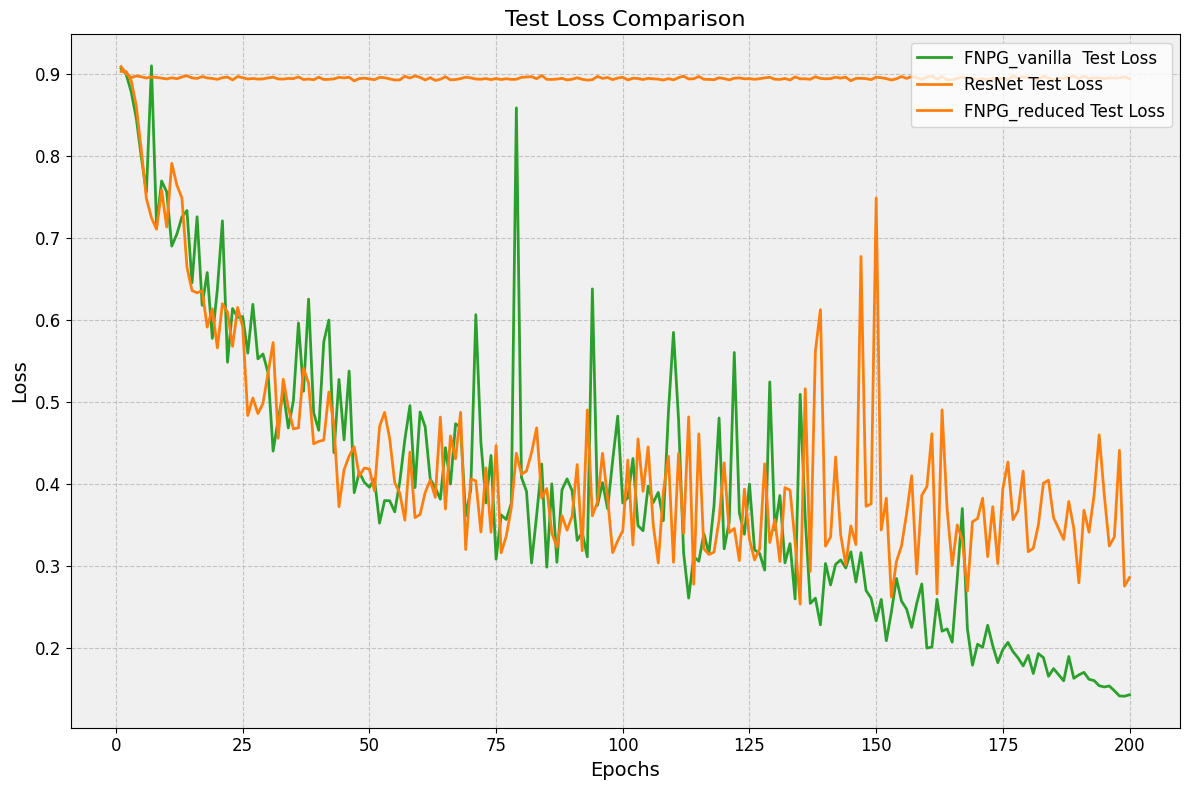

In [ ]:
#@title Figure8 & Figure 9
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datetime import datetime

# Load and convert data to lists
#train_loss_list = np.load('train_loss_epoch200_LSTM.npy').tolist()
#val_loss_list = np.load('val_loss_epoch200_LSTM.npy').tolist()
#test_loss_list_lstm = np.load('/content/drive/My Drive/test_loss_epoch200_LSTM.npy').tolist()
#train_loss_list_u = np.load('/content/drive/My Drive/train_loss_epoch200_vnila.npy').tolist()
#val_loss_list_u = np.load('/content/drive/My Drive/val_loss_epoch200_vnila.npy').tolist()
test_loss_list_fnpg = np.load('logcompletion/metrics/test_loss_epoch200_vnila.npy').tolist()
test_loss_list_rn = np.load('logcompletion/metrics/test_loss_epoch200_ResNet.npy').tolist()
test_loss_list_fnpg_2 = np.load('logcompletion/metrics/test_loss_epoch200_FNPG!.npy').tolist()

epochs = len(test_loss_list_fnpg)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot LSTM model losses
#plt.plot(range(1, epochs + 1), test_loss_list_lstm, label='LSTM Test Loss', color='#1f77b4', linewidth=2)
# plt.plot(range(1, epochs + 1), val_loss_list, label='Vanilla Val Loss', color='#ff7f0e', linewidth=2)
plt.plot(range(1, epochs + 1), test_loss_list_fnpg, label='FNPG_vanilla  Test Loss', color='#2ca02c', linewidth=2)

# Plot FNPG model losses
plt.plot(range(1, epochs + 1), test_loss_list_rn, label='ResNet Test Loss', color='#ff7f0e', linewidth=2)  # Changed color
plt.plot(range(1, epochs + 1), test_loss_list_fnpg_2[:200], label='FNPG_reduced Test Loss', color='#ff7f0e', linewidth=2)
#plt.plot(range(1, epochs + 1), test_loss_list_u, label='FNPG Test Loss', color='#d62728', linewidth=2)  # Changed color

# Customize the plot
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Test Loss Comparison', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Set the x-axis to show integers only
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# Customize the tick labels
plt.tick_params(axis='both', which='major', labelsize=12)

# Add a light gray background
plt.gca().set_facecolor('#f0f0f0')

# Tighten the layout and display the plot
plt.tight_layout()
# Save the figure
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f'/content/drive/MyDrive/logcompletion/图{timestamp}.pdf')
plt.show()

In [ ]:
import torch.optim as optim
"""
断点续训
"""
# 用于读取模型
filename = '/content/drive/MyDrive/logcompletion/model/ctra_exp_GCRR_GRSB/GCRR_GRSB50U-Net+FFE_no_metrics_record.pt'

# 载入模型、优化器，返回已经训练过的轮数
def load_model(path, model, optimizer):
    state = torch.load(path)
    model.load_state_dict(state['net'])
    #optimizer.load_state_dict(state['optimizer'])
    epoch = state['epoch']
    return epoch

# Initialize the model
model = FNPG(args.graph_channels,args.batch_size,args.fea_litho,args.head,args.drop).to(device)
model.to(device)
count_params(model)

# Define loss function and optimizer
criterion = CustomLossWithAdaptiveDerivativePenaltyAndWavelet()
optimizer = optim.Adam(list(model.parameters())+list(criterion.parameters()), lr=0.0001)

epoch_trained = load_model(filename,model,optimizer)







# Training loop
num_epochs = 10
out_list = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for a in tqdm(train_loader):
        a = a.to(device)
        a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
        optimizer.zero_grad()
        output = model(a)
        out_list.append(output)
        #plot_inputs(output.detach().cpu(),[''],range(0,512))
        loss = criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len))
        train_loss += loss.item()
        loss.backward()
        # gradient clip
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        #print(f"Epoch {epoch+1}/{num_epochs}, Batch Loss: {loss.item()}")

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss/len(train_loader)}")#注意这里的epoch不是初始模型经过的epoch，真实的轮数应该再+epoch_trained

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for a in tqdm(val_loader):
            a = a.to(device)
            a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
            output = model(a)
            val_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss/len(val_loader)}")

    if epoch % 10 == 0:
        alpha, beta, gamma = criterion.get_alpha_beta_gamma()
        print(f"Epoch {epoch}, Alpha: {alpha:.4f}, Beta: {beta:.4f}, Gamma: {gamma:.4f}")
# Evaluation
model.eval()
test_loss = 0
with torch.no_grad():
  for a in tqdm(test_loader):
    a = a.to(device)
    a.x = a.x.view(args.batch_size,len(args.fea_litho),args.sam_len)
    output = model(a)
    test_loss += criterion(output.view(args.batch_size,-1,args.sam_len), a.y.view(args.batch_size,-1,args.sam_len)).item()

print(f"Test Loss: {test_loss/len(test_loader)}")




device used in GCNN： cuda
device used in GCNN： cuda
device used in GCNN： cuda
820693581


<ipython-input-40-9aac2a8be3bf>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path)
100%|██████████| 400/400 [01:06<00:00,  6.05it/s]


Epoch 1/10, Training Loss: 0.6295558308809995


100%|██████████| 50/50 [00:02<00:00, 22.56it/s]


Epoch 1/10, Validation Loss: 0.728210346698761
Epoch 0, Alpha: 0.1040, Beta: 0.0096, Gamma: 0.0962


...

Epoch 10/10, Training Loss: 0.5990533735603094


100%|██████████| 50/50 [00:02<00:00, 22.61it/s]


Epoch 10/10, Validation Loss: 0.770088951587677


100%|██████████| 58/58 [00:02<00:00, 22.73it/s]

Test Loss: 0.7534010502798804


In [ ]:
# 保存模型，好像用不到了
def save_model(path, model, optimizer, epoch):
    state = {'net': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch}
    torch.save(state, path)

savename = f'{STAGE}' + str(num_epochs) + 'U-Net+FFE_no_metrics_record.pt'
filename = args.save_model_path + savename
# 注意这里保存的是num_epochs=50，以后的继续保存要在这之上做加法
save_model(filename,model,optimizer,num_epochs)



## after-process

In [12]:
#拿个井做整井的预测成图 注意index
well_x_pt = tensor_list_x[0].clone()#tensor_list_x的有91个items，对应91口井
well_y_pt = tensor_list_y[0].clone()

#第一口井是15/9-15 注意index
well_list_target_ = torch.cat((tensor_list_target[0][:,1:,:].clone(),tensor_list_target_2[0][:,1:3,:].clone()),dim=1)
#well_list_target_ = tensor_list_target[0][:,1,:].clone().unsqueeze(1)
well_target_pt = well_list_target_.clone()

In [ ]:
well_x_pt.shape, well_y_pt.shape, well_target_pt.shape

(torch.Size([34, 4, 512]), torch.Size([34, 4, 512]), torch.Size([34, 5, 512]))

In [ ]:
# 这个cell不运行
well_x_pt_2 = tensor_list_x[1].clone()#tensor_list_x的有91个items，对应91口井
well_y_pt_2 = tensor_list_y[1].clone()

#第二口井是15/9-17 注意index
well_list_target_2 = torch.cat((tensor_list_target[1][:,1:,:].clone(),tensor_list_target_2[1][:,1:3,:].clone()),dim=1)
well_target_pt_2 = well_list_target_2.clone()

In [13]:
assert well_y_pt.shape[0] == well_target_pt.shape[0]


infer_dataset = my_dataset(well_y_pt, well_target_pt) #输入值，标签值
from torch.utils.data import DataLoader
# 使用标准的 PyTorch DataLoader
infer_loader = DataLoader(
    infer_dataset,
    batch_size=2,#2
    num_workers=0,
    shuffle=False,
    drop_last=True,
    collate_fn=custom_collate  # 使用自定义的collate_fn
)
import torch.optim as optim
model = FNPG(args.graph_channels,2,args.fea_litho,args.head,args.drop).to(device)

criterion = CustomLossWithAdaptiveDerivativePenaltyAndWavelet()
optimizer = optim.Adam(list(model.parameters())+list(criterion.parameters()), lr=0.001, weight_decay=1e-4)

STAGE = 'GCRR_GRSB'
savename = f'{STAGE}' + '200' + 'FNPG_final.pt' #要保存的模型
filename = args.save_model_path + savename
# 读取最好的模型
model, optimizer, best_epoch, best_loss = load_best_model(model, optimizer, filename)
#print(f"Loaded best model from epoch {best_epoch} with validation loss {best_loss}")
# out_list存储模型的预测
out_list = []
for i in infer_loader:
  i.x = i.x.view(-1,4,512)
  output = model(i)
  out_list.append(output)
out_list = torch.cat(out_list,dim=0)
# 链式写法针对一个预测曲线
#out_list = out_list.unsqueeze(1)
# out_list:(32,4,512)将它整井的长度放在最后一维
print(out_list.shape)
out_list = out_list.permute(1,0,2).reshape(-1,out_list.size(0)*out_list.size(2))
well_target_pt = well_target_pt.permute(1,0,2).reshape(-1,well_target_pt.size(0)*well_target_pt.size(2))
well_y_pt = well_y_pt.permute(1,0,2).reshape(-1,well_y_pt.size(0)*well_y_pt.size(2))
well_x_pt = well_x_pt.permute(1,0,2).reshape(-1,well_x_pt.size(0)*well_x_pt.size(2))
print(well_y_pt.shape)
print(well_x_pt.shape)

device used in conv_obj： cuda
device used in conv_obj： cuda
device used in conv_obj： cuda
torch.Size([34, 5, 512])
torch.Size([4, 17408])
torch.Size([4, 17408])


In [14]:
#15.9-15
well_name = '15/9-15'
single_well = train_ori_set_2[train_ori_set_2['WELL'] == f'{well_name}'].copy()
assert single_well.shape[0] != 0, "single_well is empty"
selected = single_well[['CALI', 'RSHA', 'RMED',  'RDEP', 'SP']].copy()
print(f'{well_name}元数据长度为',selected.shape)
selected = selected.reset_index(drop=True).values.tolist()#注意，滑动截取的井数据index都会reset，回想自己之前写的算法
"""
15/9-15井的元数据长度为17717，well_target_pt是512窗口滑动的该井数据，长度为17,408 二者相差309
"""
selected = torch.tensor(selected).transpose(0, 1)
## 在15.9-15井中选取GR,NPHI,RHOB和DTC，画Missing reconstruction部分
selected_4rc = single_well[['GR','NPHI','RHOB','DTC']].copy()#for reconstruction
print(f'{well_name}用于重建的元数据长度为',selected_4rc.shape)
selected_4rc = selected_4rc.reset_index(drop=True).values.tolist()
selected_4rc = torch.tensor(selected_4rc).transpose(0, 1)

15/9-15元数据长度为 (17717, 5)
15/9-15用于重建的元数据长度为 (17717, 4)


In [ ]:
#15.9-17
well_name = '15/9-17'
single_well = train_ori_set_2[train_ori_set_2['WELL'] == f'{well_name}'].copy()
assert single_well.shape[0] != 0, "single_well is empty"
selected = single_well[['CALI', 'RSHA', 'RMED',  'RDEP', 'SP']].copy()
print(f'{well_name}元数据长度为',selected.shape)
selected = selected.reset_index(drop=True).values.tolist()#注意，滑动截取的井数据index都会reset，回想自己之前写的算法
"""
15/9-17井的元数据长度为17350，well_target_pt是512窗口滑动的该井数据，长度为16,384 二者相差966
"""
selected = torch.tensor(selected).transpose(0, 1)

## 在15.9-17井中选取GR,NPHI,RHOB和DTC，画Missing reconstruction部分
selected_4rc = single_well[['GR','NPHI','RHOB','DTC']].copy()#for reconstruction
print(f'{well_name}用于重建的元数据长度为',selected_4rc.shape)
selected_4rc = selected_4rc.reset_index(drop=True).values.tolist()
selected_4rc = torch.tensor(selected_4rc).transpose(0, 1)

15/9-17元数据长度为 (17350, 5)
15/9-17用于重建的元数据长度为 (17350, 4)


In [15]:
print(well_target_pt.shape)
print(well_y_pt.shape)
print(out_list.shape)
print(selected.shape)
print(selected_4rc.shape)
# 链式写法
selected = selected[:,:well_target_pt.shape[1]]
selected_4rc = selected_4rc[:,:well_target_pt.shape[1]]

# 使用 torch.nan_to_num() 将 NaN 值替换为 1000
selected_filled = torch.nan_to_num(selected, nan=5.0)
print(selected_filled.shape)


torch.Size([5, 17408])
torch.Size([4, 17408])
torch.Size([5, 17408])
torch.Size([5, 17717])
torch.Size([4, 17717])
torch.Size([5, 17408])


In [16]:
# 避免上下i变量名的混淆
i = 0

In [18]:
# Make predictions on train_loader
with torch.no_grad():
    a = next(iter(infer_loader))
    a.x = a.x.view(2,len(args.fea_litho),args.sam_len) #2 != args.batch_size
    predictions = model(a)
    i+=1
    print(f'{i} iteration')

1 iteration


In [19]:
# 这一个cell写了两遍，第一遍
## 将预测值加上 meta与模型输入值的 差值
#target = selected_filled.detach().cpu().unsqueeze(0)
# selected_filled是原数据为了shape将NAN转换为5的
#target_plot = np.where(target[0, i, :] == 5, np.nan, target[0, i, :])
# 创建一个与target相同形状的全零数组
#mask_list = np.zeros_like(target, dtype=float)

# 将target中值为5的位置在mask_list中设为NaN，mask_list与well_target_pt.detach().cpu().unsqueeze(0)相加
#mask_list[target == 5] = np.nan

label = well_target_pt.detach().cpu().unsqueeze(0)#标准化的标签
#meta = selected_filled.detach().cpu().unsqueeze(0)#原数据meta,NAN值都化为5
# 使用 torch.nan_to_num 将 NaN 转换为 0
#meta = torch.nan_to_num(meta, nan=0.0)
input = well_y_pt.detach().cpu().unsqueeze(0)#模型输入值
predict = out_list.detach().cpu().unsqueeze(0)#模型预测值

# out_list 因为drop_last=True,丢了一部分
#diff = meta - label
#predict_diffAdd = predict + diff

#print(predict_diffAdd.shape)
# 上去再跑另一个井

In [ ]:
# 这一个cell写了两遍，第二遍
## 将预测值加上 meta与模型输入值的 差值
target_2 = selected_filled.detach().cpu().unsqueeze(0)
# selected_filled是原数据为了shape将NAN转换为5的
target_plot = np.where(target_2[0, i, :] == 5, np.nan, target_2[0, i, :])
# 创建一个与target相同形状的全零数组
mask_list = np.zeros_like(target_2, dtype=float)

# 将target中值为5的位置在mask_list中设为NaN，mask_list与well_target_pt.detach().cpu().unsqueeze(0)相加
mask_list[target_2 == 5] = np.nan

label_2 = well_target_pt.detach().cpu().unsqueeze(0)#标准化的标签
meta_2 = selected_filled.detach().cpu().unsqueeze(0)#原数据meta,NAN值都化为5
# 使用 torch.nan_to_num 将 NaN 转换为 0
meta_2 = torch.nan_to_num(meta_2, nan=0.0)
input_2 = well_y_pt.detach().cpu().unsqueeze(0)#模型输入值
predict_2 = out_list.detach().cpu().unsqueeze(0)#模型预测值

# out_list 因为drop_last=True,丢了一部分
diff_2 = meta_2 - label_2
predict_diffAdd_2 = predict_2 + diff_2

print(predict_diffAdd_2.shape)

torch.Size([1, 5, 16896])


In [20]:
#@title Figure12
# Visualize results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
def plot_results(data, predictions, target, log_names, depth, fig_size=(20, 24), dpi=300):
    """
    Plot the results of well log predictions in an academic style, leaving gaps for values equal to 5.

    Parameters:
    - data (numpy.ndarray): Input well log data of shape (n_samples, n_logs, depth)
    - predictions (numpy.ndarray): Predicted well log data of shape (n_samples, n_predicted_logs, depth)
    - target (numpy.ndarray): Actual target well log data of shape (n_samples, n_predicted_logs, depth)
    - log_names (list): List of names for input and predicted logs
    - depth (numpy.ndarray): Depth values for the well logs
    - fig_size (tuple): Figure size (width, height) in inches
    - dpi (int): Dots per inch for the figure

    Returns:
    - fig (matplotlib.figure.Figure): The created figure object
    """

    # Set the style for the plots
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

    # Move tensors to CPU and convert to NumPy arrays
    data = data.cpu().numpy()
    n_input_logs = data.shape[1]

    if target is not None:
      predictions = predictions.cpu().numpy()
      target = target.cpu().numpy()

      n_predicted_logs = predictions.shape[1]

      # Create subplots
      fig, axs = plt.subplots(1, n_input_logs + n_predicted_logs + 1, figsize=fig_size, dpi=dpi, sharey=True)
      fig.suptitle("Well Log Prediction Results", fontsize=24, fontweight='bold')

      # Plot input logs
      for i in range(n_input_logs):
          axs[i].plot(data[0, i, :], depth, label='Actual', color='black', linewidth=0.5)
          axs[i].set_title(log_names[i], fontsize=16)
          axs[i].set_xlabel(log_names[i] + ' Value', fontsize=12)
          axs[i].invert_yaxis()
          axs[i].grid(True, which='both', linestyle='--', linewidth=0.5)
          axs[i].tick_params(axis='both', which='major', labelsize=10)

      # Plot predicted vs actual logs, leaving gaps for target values equal to 5
      for i in range(n_predicted_logs):

          predictions_plot = np.where(target[0, i, :] == 5, np.nan, predictions[0, i, :])#只给元数据赋值NAN，预测值保留以显示reconstrcution.

          axs[n_input_logs + i].plot(target[0, i, :], depth, label='Actual', color='black', linewidth=0.5)#这里的target是传入的target_plot
          axs[n_input_logs + i].plot(predictions[0, i, :], depth, label='Predicted', color='red', linewidth=0.5, linestyle='--')
          axs[n_input_logs + i].set_title(log_names[n_input_logs + i], fontsize=16)
          axs[n_input_logs + i].set_xlabel(log_names[n_input_logs + i] + ' Value', fontsize=12)
          axs[n_input_logs + i].legend(fontsize=10)
          axs[n_input_logs + i].grid(True, which='both', linestyle='--', linewidth=0.5)
          axs[n_input_logs + i].tick_params(axis='both', which='major', labelsize=10)

      # Set common y-label
      fig.text(0.04, 0.5, 'Depth (m)', va='center', rotation='vertical', fontsize=14)

      # Plot error distribution and cross-plot
      error = predictions[0, 0, :] - target[0, 0, :]
      ax_hist = axs[-1]
      sns.histplot(error, kde=True, ax=ax_hist)
      ax_hist.set_title('Error Distribution', fontsize=16)
      ax_hist.set_xlabel('Error', fontsize=12)
      ax_hist.set_ylabel('Frequency', fontsize=12)

      # Add statistical information to the error distribution plot
      mean_error = np.mean(error)
      std_error = np.std(error)
      rmse = np.sqrt(np.mean(error**2))
      r2 = stats.pearsonr(predictions[0, 0, :], target[0, 0, :])[0]**2

      stats_text = f'Mean: {mean_error:.2f}\nStd: {std_error:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}'
      ax_hist.text(0.95, 0.95, stats_text, transform=ax_hist.transAxes, fontsize=10,
                  verticalalignment='top', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

      # Adjust layout and display the plot
      plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])

      # Add a cross-plot as an inset axis in the error distribution subplot
      ax_cross = ax_hist.inset_axes([0.05, 0.6, 0.4, 0.35])
      ax_cross.scatter(target[0, 0, :], predictions[0, 0, :], alpha=0.5, s=1)
      ax_cross.set_xlabel('Actual', fontsize=8)
      ax_cross.set_ylabel('Predicted', fontsize=8)
      ax_cross.set_title('Cross-plot', fontsize=10)

      # Add a 45-degree reference line
      lims = [
          np.min([ax_cross.get_xlim(), ax_cross.get_ylim()]),
          np.max([ax_cross.get_xlim(), ax_cross.get_ylim()]),
      ]
      ax_cross.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
      ax_cross.set_aspect('equal')
      ax_cross.tick_params(axis='both', which='major', labelsize=6)
    else:
      # Create subplots
      fig, axs = plt.subplots(1, n_input_logs, figsize=fig_size, dpi=dpi, sharey=True)
      fig.suptitle("Well Log Reconstruction Results", fontsize=24, fontweight='bold')

      # Plot input logs
      for i in range(n_input_logs):
          axs[i].plot(data[0, i, :], depth, label='Actual', color='black', linewidth=0.5)
          axs[i].plot(predictions[0, i, :], depth, label='Reconstruction', color='red', linewidth=0.5, linestyle='--')#这里的predictions变量是上一个IF定义中的data
          axs[i].set_title(log_names[i], fontsize=16)
          axs[i].set_xlabel(log_names[i] + ' Value', fontsize=12)
          axs[i].invert_yaxis()
          axs[i].grid(True, which='both', linestyle='--', linewidth=0.5)
          axs[i].tick_params(axis='both', which='major', labelsize=10)

      # Set common y-label
      fig.text(0.04, 0.5, 'Depth (m)', va='center', rotation='vertical', fontsize=14)

    return fig

# Example usage:
# Assuming you have the following variables:
# - data: input well log data
# - predictions: predicted well log data
# - target: actual target well log data
# - depth: depth values for the well logs

log_names = ['GR', 'RHOB', 'NPHI', 'DTC','CALI', 'RSHA', 'RMED',  'RDEP', 'SP']
depth = np.arange(0, out_list.shape[-1]) #np.arange(0, 512)

print(input.shape, predict.shape, label.shape)
fig = plot_results(input, predict, label, log_names, depth)

#注意，15.9-15井没有NAN值，因此mask_list全是初始的-inf，进入plot_results函数会报错

#fig = plot_results(well_y_pt.detach().cpu().unsqueeze(0), predict_diffAdd,#predict
#                   label_2, log_names = ['GR', 'RHOB', 'NPHI', 'DTC',#+mask_list
#                  'CALI', 'RSHA', 'RMED',  'RDEP', 'SP'], depth=np.arange(0, out_list.shape[-1])) #well_target_pt

#fig = plot_results(well_y_pt.detach().cpu().unsqueeze(0), predict_diffAdd_2[:,:,:well_y_pt.shape[-1]],#out_list.detach().cpu().unsqueeze(0),
#                  selected_filled.detach().cpu().unsqueeze(0)+mask_list, log_names = log_names, depth=depth)

# Missing Reconstruction
#selected_4rc_ = selected_4rc.detach().cpu().unsqueeze(0)
#mask = torch.where(torch.isnan(selected_4rc_), selected_4rc_, torch.tensor(0.0))
#fig = plot_results(well_x_pt.detach().cpu().unsqueeze(0)+mask, well_y_pt.detach().cpu().unsqueeze(0), None, log_names, depth)
from datetime import datetime
# 获取当前时间并格式化为字符串
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"/content/drive/MyDrive/logcompletion/15.9-15_缺失重建和模型预测及标签未标准化_矢量图{timestamp}.pdf"
#plt.savefig(filename, format='pdf', dpi=600, bbox_inches='tight')

#plt.close(fig)

Output hidden; open in https://colab.research.google.com to view.

## back up

In [ ]:
# 绘图 Missing Well log reconstruction
# 这部分需要调用第一个模型，代码放在inferencing.ipynb当中了


In [ ]:
out_list.detach().cpu().unsqueeze(0).shape


torch.Size([1, 7, 16384])

In [ ]:
def plot_results_former(data, predictions, target, log_names, depth, fig_size=(20, 24), dpi=300):
    """
    Plot the results of well log predictions in an academic style.

    Parameters:
    - data (numpy.ndarray): Input well log data of shape (n_samples, n_logs, depth)
    - predictions (numpy.ndarray): Predicted well log data of shape (n_samples, n_predicted_logs, depth)
    - target (numpy.ndarray): Actual target well log data of shape (n_samples, n_predicted_logs, depth)
    - log_names (list): List of names for input and predicted logs
    - depth (numpy.ndarray): Depth values for the well logs
    - fig_size (tuple): Figure size (width, height) in inches
    - dpi (int): Dots per inch for the figure

    Returns:
    - fig (matplotlib.figure.Figure): The created figure object
    """

    # Set the style for the plots
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

    # Move tensors to CPU and convert to NumPy arrays
    data = data.cpu().numpy()
    predictions = predictions.cpu().numpy()
    target = target.cpu().numpy()

    n_input_logs = data.shape[1]
    n_predicted_logs = predictions.shape[1]
    # Create subplots
    fig, axs = plt.subplots(1, n_input_logs + n_predicted_logs + 1, figsize=fig_size, dpi=dpi, sharey=True)
    fig.suptitle("Well Log Prediction Results", fontsize=24, fontweight='bold')

    # Plot input logs
    for i in range(n_input_logs):
        axs[i].plot(data[0, i, :], depth, label='Actual', color='black', linewidth=0.5)
        axs[i].set_title(log_names[i], fontsize=16)
        axs[i].set_xlabel(log_names[i] + ' Value', fontsize=12)
        axs[i].invert_yaxis()
        axs[i].grid(True, which='both', linestyle='--', linewidth=0.5)
        axs[i].tick_params(axis='both', which='major', labelsize=10)

    # Plot predicted vs actual logs
    for i in range(n_predicted_logs):
        axs[n_input_logs + i].plot(target[0, i, :], depth, label='Actual', color='black', linewidth=0.5)
        axs[n_input_logs + i].plot(predictions[0, i, :], depth, label='Predicted', color='red', linewidth=0.5, linestyle='--')
        axs[n_input_logs + i].set_title(log_names[n_input_logs + i], fontsize=16)
        axs[n_input_logs + i].set_xlabel(log_names[n_input_logs + i] + ' Value', fontsize=12)
        axs[n_input_logs + i].legend(fontsize=10)
        axs[n_input_logs + i].grid(True, which='both', linestyle='--', linewidth=0.5)
        axs[n_input_logs + i].tick_params(axis='both', which='major', labelsize=10)

    # Set common y-label
    fig.text(0.04, 0.5, 'Depth (m)', va='center', rotation='vertical', fontsize=14)

    # Plot error distribution and cross-plot
    error = predictions[0, 0, :] - target[0, 0, :]
    ax_hist = axs[-1]
    sns.histplot(error, kde=True, ax=ax_hist)
    ax_hist.set_title('Error Distribution', fontsize=16)
    ax_hist.set_xlabel('Error', fontsize=12)
    ax_hist.set_ylabel('Frequency', fontsize=12)

    # Add statistical information to the error distribution plot
    mean_error = np.mean(error)
    std_error = np.std(error)
    rmse = np.sqrt(np.mean(error**2))
    r2 = stats.pearsonr(predictions[0, 0, :], target[0, 0, :])[0]**2

    stats_text = f'Mean: {mean_error:.2f}\nStd: {std_error:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}'
    ax_hist.text(0.95, 0.95, stats_text, transform=ax_hist.transAxes, fontsize=10,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Adjust layout and display the plot
    plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])

    # Add a cross-plot as an inset axis in the error distribution subplot
    ax_cross = ax_hist.inset_axes([0.05, 0.6, 0.4, 0.35])
    ax_cross.scatter(target[0, 0, :], predictions[0, 0, :], alpha=0.5, s=1)
    ax_cross.set_xlabel('Actual', fontsize=8)
    ax_cross.set_ylabel('Predicted', fontsize=8)
    ax_cross.set_title('Cross-plot', fontsize=10)

    # Add a 45-degree reference line
    lims = [
        np.min([ax_cross.get_xlim(), ax_cross.get_ylim()]),
        np.max([ax_cross.get_xlim(), ax_cross.get_ylim()]),
    ]
    ax_cross.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    ax_cross.set_aspect('equal')
    ax_cross.tick_params(axis='both', which='major', labelsize=6)

    return fig

Output hidden; open in https://colab.research.google.com to view.